# Vehicle Damage Assessment System - Data Preprocessing & EDA

**Project:** Smart Repair Locator - Garage Recommendation System


**Objective:** Load, clean, validate, and explore synthetic datasets for garage recommendation ML model

---

## Table of Contents
1. [Setup & Import Libraries](#section1)
2. [Load Datasets](#section2)
3. [Data Quality Assessment](#section3)
4. [Data Cleaning](#section4)
5. [Exploratory Data Analysis (EDA)](#section5)
6. [Data Validation](#section6)
7. [Save Cleaned Data](#section7)

---
<a id='section1'></a>
## 1. Setup & Import Libraries

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(" Libraries imported successfully!")
print(f" Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 Libraries imported successfully!
 Analysis Date: 2025-11-19 14:09:31


---
<a id='section2'></a>
## 2. Load Datasets

In [6]:
# Define file paths
DATA_PATH = 'data/'

file_paths = {
    'garages': DATA_PATH + 'garages_sri_lanka_synthetic.csv',
    'repairs': DATA_PATH + 'vehicle_repairs_sri_lanka_synthetic.csv',
    'users': DATA_PATH + 'user_profiles_vehicle_owners_sri_lanka.csv',
    'damage_ref': DATA_PATH + 'damage_reference_dataset.csv',
    'spare_parts': DATA_PATH + 'toyota_sri_lanka_spare_parts_prices.csv',
    'specializations': DATA_PATH + 'garage_specializations_dataset.csv',
    'capacity': DATA_PATH + 'garage_capacity_timeseries.csv'
}

# Load all datasets
print("📂 Loading datasets...\n")

garages_df = pd.read_csv(file_paths['garages'])
print(f"✓ Garages: {garages_df.shape[0]} rows × {garages_df.shape[1]} columns")

repairs_df = pd.read_csv(file_paths['repairs'])
print(f"✓ Repairs: {repairs_df.shape[0]} rows × {repairs_df.shape[1]} columns")

users_df = pd.read_csv(file_paths['users'])
print(f"✓ Users: {users_df.shape[0]} rows × {users_df.shape[1]} columns")

damage_ref_df = pd.read_csv(file_paths['damage_ref'])
print(f"✓ Damage Reference: {damage_ref_df.shape[0]} rows × {damage_ref_df.shape[1]} columns")

spare_parts_df = pd.read_csv(file_paths['spare_parts'])
print(f"✓ Spare Parts: {spare_parts_df.shape[0]} rows × {spare_parts_df.shape[1]} columns")

specializations_df = pd.read_csv(file_paths['specializations'])
print(f"✓ Specializations: {specializations_df.shape[0]} rows × {specializations_df.shape[1]} columns")

capacity_df = pd.read_csv(file_paths['capacity'])
print(f"✓ Capacity Timeline: {capacity_df.shape[0]} rows × {capacity_df.shape[1]} columns")

print("\n✅ All datasets loaded successfully!")

📂 Loading datasets...

✓ Garages: 100 rows × 17 columns
✓ Repairs: 1000 rows × 20 columns
✓ Users: 400 rows × 16 columns
✓ Damage Reference: 90 rows × 15 columns
✓ Spare Parts: 819 rows × 6 columns
✓ Specializations: 294 rows × 10 columns
✓ Capacity Timeline: 36500 rows × 12 columns

✅ All datasets loaded successfully!


---
<a id='section3'></a>
## 3. Data Quality Assessment

### 3.1 Garages Dataset

In [7]:
print("="*80)
print("GARAGES DATASET - INITIAL ASSESSMENT")
print("="*80)

print("\n📊 First 5 rows:")
display(garages_df.head())

print("\n📋 Dataset Info:")
garages_df.info()

print("\n📈 Statistical Summary:")
display(garages_df.describe())

print("\n🔍 Missing Values:")
missing_garages = garages_df.isnull().sum()
missing_garages = missing_garages[missing_garages > 0].sort_values(ascending=False)
if len(missing_garages) > 0:
    print(missing_garages)
else:
    print("✅ No missing values!")

print("\n🔢 Unique Values:")
for col in garages_df.columns:
    print(f"{col}: {garages_df[col].nunique()} unique values")

GARAGES DATASET - INITIAL ASSESSMENT

📊 First 5 rows:


,garage_id,name,latitude,longitude,city,specializations,avg_rating,num_reviews,completion_rate,avg_completion_days,total_bays,available_bays,avg_hourly_rate,price_range,equipment_score,certified,years_in_business
0,GAR001,Metro Garage Nugegoda,6.708,79.855,Nugegoda,general_repair,4.140,32,0.902,3.720,2,0,3824,mid_range,0.826,1,3
1,GAR002,Modern Auto Works Colombo,6.881,79.912,Colombo,"ac_repair,electrical,engine_repair,transmission",4.460,179,0.904,2.630,8,4,4518,premium,0.807,0,26
2,GAR003,Quick Motor Works Colombo,6.987,79.867,Colombo,suspension,3.820,54,0.899,2.780,5,4,2638,mid_range,0.722,1,28
3,GAR004,Prime Auto House Colombo,6.977,79.816,Colombo,"body_work,electrical,paint_work",3.650,15,0.881,5.100,3,0,2886,budget,0.739,1,22
4,GAR005,City Car Care Dehiwala,6.836,79.967,Dehiwala,"electrical,suspension,transmission",3.950,28,0.887,3.280,4,1,2925,mid_range,0.769,1,30



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   garage_id            100 non-null    object 
 1   name                 100 non-null    object 
 2   latitude             100 non-null    float64
 3   longitude            100 non-null    float64
 4   city                 100 non-null    object 
 5   specializations      100 non-null    object 
 6   avg_rating           100 non-null    float64
 7   num_reviews          100 non-null    int64  
 8   completion_rate      100 non-null    float64
 9   avg_completion_days  100 non-null    float64
 10  total_bays           100 non-null    int64  
 11  available_bays       100 non-null    int64  
 12  avg_hourly_rate      100 non-null    int64  
 13  price_range          100 non-null    object 
 14  equipment_score      100 non-null    float64
 15  certified            100

,latitude,longitude,avg_rating,num_reviews,completion_rate,avg_completion_days,total_bays,available_bays,avg_hourly_rate,equipment_score,certified,years_in_business
count,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
mean,6.847,79.890,4.051,59.990,0.891,4.004,5.460,2.890,3348.720,0.747,0.600,16.770
std,0.090,0.056,0.219,69.639,0.016,1.467,1.611,2.117,927.496,0.053,0.492,9.241
min,6.700,79.802,3.640,15.000,0.854,1.500,2.000,0.000,1500.000,0.605,0.000,1.000
25%,6.776,79.845,3.888,18.000,0.881,2.828,4.000,1.000,2605.000,0.715,0.000,8.750
50%,6.823,79.879,4.030,36.000,0.889,3.945,5.000,3.000,3443.500,0.746,1.000,17.500
75%,6.923,79.938,4.183,66.500,0.901,5.043,6.250,5.000,3953.250,0.788,1.000,26.000
max,6.995,79.999,4.660,481.000,0.927,7.830,9.000,8.000,5714.000,0.882,1.000,30.000



🔍 Missing Values:
✅ No missing values!

🔢 Unique Values:
garage_id: 100 unique values
name: 97 unique values
latitude: 100 unique values
longitude: 100 unique values
city: 8 unique values
specializations: 72 unique values
avg_rating: 63 unique values
num_reviews: 61 unique values
completion_rate: 52 unique values
avg_completion_days: 90 unique values
total_bays: 8 unique values
available_bays: 9 unique values
avg_hourly_rate: 97 unique values
price_range: 3 unique values
equipment_score: 78 unique values
certified: 2 unique values
years_in_business: 27 unique values


### 3.2 Repairs Dataset

In [8]:
print("="*80)
print("REPAIRS DATASET - INITIAL ASSESSMENT")
print("="*80)

print("\n📊 First 5 rows:")
display(repairs_df.head())

print("\n📋 Dataset Info:")
repairs_df.info()

print("\n📈 Statistical Summary:")
display(repairs_df.describe())

print("\n🔍 Missing Values:")
missing_repairs = repairs_df.isnull().sum()
missing_repairs = missing_repairs[missing_repairs > 0].sort_values(ascending=False)
if len(missing_repairs) > 0:
    print(missing_repairs)
else:
    print("✅ No missing values!")

print("\n🔢 Unique Values:")
for col in repairs_df.columns:
    print(f"{col}: {repairs_df[col].nunique()} unique values")

REPAIRS DATASET - INITIAL ASSESSMENT

📊 First 5 rows:


,repair_id,garage_id,user_id,damage_type,damage_location,repair_category,user_location_lat,user_location_lon,distance_to_garage,vehicle_make,vehicle_year,final_cost,estimated_cost,completion_days,user_satisfied,satisfaction_score,would_recommend,repair_date,parts_replaced,insurance_claimed
0,REP0001,GAR035,USER027,minor,windshield,glass_repair,7.006,79.749,18.340,Honda,2015,20122,16202,1,1,0.516,0,2023-12-08,headlight,1
1,REP0002,GAR081,USER224,moderate,windshield,glass_repair,6.887,79.898,11.250,Mercedes,2016,64837,56992,3,1,0.657,1,2024-05-03,"front_bumper,trunk_lid",0
2,REP0003,GAR027,USER176,moderate,headlight,electrical,6.654,79.956,15.630,Suzuki,2020,75239,65979,6,1,0.815,1,2024-07-05,"ac_condenser,paint,side_mirror",0
3,REP0004,GAR041,USER249,moderate,windshield,glass_repair,6.790,79.846,3.580,Toyota,2016,98844,115233,4,1,0.542,0,2024-07-21,"radiator,rear_bumper",0
4,REP0005,GAR019,USER294,moderate,front_bumper,body_work,6.882,79.918,5.950,Toyota,2019,97965,83584,3,1,0.585,0,2024-05-21,"radiator,tail_light,windshield",0



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   repair_id           1000 non-null   object 
 1   garage_id           1000 non-null   object 
 2   user_id             1000 non-null   object 
 3   damage_type         1000 non-null   object 
 4   damage_location     1000 non-null   object 
 5   repair_category     1000 non-null   object 
 6   user_location_lat   1000 non-null   float64
 7   user_location_lon   1000 non-null   float64
 8   distance_to_garage  1000 non-null   float64
 9   vehicle_make        1000 non-null   object 
 10  vehicle_year        1000 non-null   int64  
 11  final_cost          1000 non-null   int64  
 12  estimated_cost      1000 non-null   int64  
 13  completion_days     1000 non-null   int64  
 14  user_satisfied      1000 non-null   int64  
 15  satisfaction_score  1000 non-null   flo

,user_location_lat,user_location_lon,distance_to_garage,vehicle_year,final_cost,estimated_cost,completion_days,user_satisfied,satisfaction_score,would_recommend,insurance_claimed
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,6.845,79.896,13.254,2016.106,106866.654,106338.917,4.675,0.737,0.639,0.451,0.352
std,0.123,0.105,4.718,3.969,119522.030,122283.766,3.400,0.440,0.083,0.498,0.478
min,6.526,79.639,0.880,2005.000,10242.000,9023.000,1.000,0.000,0.374,0.000,0.000
25%,6.758,79.818,9.960,2014.000,28232.250,27837.750,2.000,0.000,0.584,0.000,0.000
50%,6.844,79.894,13.910,2016.000,65867.500,60035.000,3.000,1.000,0.638,0.000,0.000
75%,6.929,79.975,17.160,2019.000,103632.750,107436.500,6.000,1.000,0.695,1.000,1.000
max,7.157,80.163,20.030,2024.000,496638.000,589146.000,15.000,1.000,0.864,1.000,1.000



🔍 Missing Values:
✅ No missing values!

🔢 Unique Values:
repair_id: 1000 unique values
garage_id: 100 unique values
user_id: 359 unique values
damage_type: 3 unique values
damage_location: 9 unique values
repair_category: 6 unique values
user_location_lat: 999 unique values
user_location_lon: 999 unique values
distance_to_garage: 729 unique values
vehicle_make: 8 unique values
vehicle_year: 20 unique values
final_cost: 993 unique values
estimated_cost: 996 unique values
completion_days: 15 unique values
user_satisfied: 2 unique values
satisfaction_score: 330 unique values
would_recommend: 2 unique values
repair_date: 534 unique values
parts_replaced: 358 unique values
insurance_claimed: 2 unique values


### 3.3 Users Dataset

In [9]:
print("="*80)
print("USERS DATASET - INITIAL ASSESSMENT")
print("="*80)

print("\n📊 First 5 rows:")
display(users_df.head())

print("\n📋 Dataset Info:")
users_df.info()

print("\n📈 Statistical Summary:")
display(users_df.describe())

print("\n🔍 Missing Values:")
missing_users = users_df.isnull().sum()
missing_users = missing_users[missing_users > 0].sort_values(ascending=False)
if len(missing_users) > 0:
    print(missing_users)
else:
    print("✅ No missing values!")

USERS DATASET - INITIAL ASSESSMENT

📊 First 5 rows:


,user_id,user_location_lat,user_location_lon,city,preferred_price_range,max_acceptable_distance,min_acceptable_rating,importance_speed,importance_cost,importance_quality,importance_proximity,vehicle_count,avg_repairs_per_year,age_group,occupation,insurance_holder
0,USER001,6.775,79.833,Maharagama,mid_range,10,4.500,0.611,0.602,0.993,0.943,2,2.000,60+,retired,0
1,USER002,6.966,79.952,Colombo,mid_range,5,3.500,0.538,0.293,0.487,0.447,1,0.500,60+,business_owner,1
2,USER003,6.873,79.829,Moratuwa,mid_range,10,4.500,0.441,0.850,1.000,0.816,2,0.500,51-60,employee,0
3,USER004,6.917,79.936,Moratuwa,mid_range,20,3.500,0.481,0.734,0.375,0.381,2,0.500,31-40,employee,0
4,USER005,6.863,79.971,Dehiwala,mid_range,25,4.000,0.534,0.546,0.669,0.705,2,2.000,41-50,business_owner,0



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  400 non-null    object 
 1   user_location_lat        400 non-null    float64
 2   user_location_lon        400 non-null    float64
 3   city                     400 non-null    object 
 4   preferred_price_range    400 non-null    object 
 5   max_acceptable_distance  400 non-null    int64  
 6   min_acceptable_rating    400 non-null    float64
 7   importance_speed         400 non-null    float64
 8   importance_cost          400 non-null    float64
 9   importance_quality       400 non-null    float64
 10  importance_proximity     400 non-null    float64
 11  vehicle_count            400 non-null    int64  
 12  avg_repairs_per_year     400 non-null    float64
 13  age_group                400 non-null    object 
 14  occupatio

,user_location_lat,user_location_lon,max_acceptable_distance,min_acceptable_rating,importance_speed,importance_cost,importance_quality,importance_proximity,vehicle_count,avg_repairs_per_year,insurance_holder
count,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000,400.000
mean,6.851,79.897,10.752,3.796,0.522,0.566,0.701,0.516,1.520,1.212,0.520
std,0.086,0.059,6.236,0.428,0.171,0.228,0.207,0.181,0.704,0.754,0.500
min,6.701,79.800,3.000,3.000,0.002,0.000,0.083,0.000,1.000,0.500,0.000
25%,6.777,79.844,5.000,3.500,0.406,0.405,0.560,0.398,1.000,0.500,0.000
50%,6.857,79.894,10.000,4.000,0.523,0.564,0.698,0.526,1.000,1.000,1.000
75%,6.921,79.947,15.000,4.000,0.637,0.734,0.864,0.642,2.000,2.000,1.000
max,7.000,79.999,25.000,4.500,1.000,1.000,1.000,1.000,3.000,3.000,1.000



🔍 Missing Values:
✅ No missing values!


### 3.4 Other Datasets Quick Check

In [10]:
print("="*80)
print("OTHER DATASETS - QUICK CHECK")
print("="*80)

datasets = {
    'Damage Reference': damage_ref_df,
    'Spare Parts': spare_parts_df,
    'Specializations': specializations_df,
    'Capacity Timeline': capacity_df
}

for name, df in datasets.items():
    print(f"\n📊 {name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    print(f"  Columns: {list(df.columns)}")
    display(df.head(3))

OTHER DATASETS - QUICK CHECK

📊 Damage Reference:
  Shape: (90, 15)
  Missing values: 0
  Columns: ['damage_id', 'damage_type', 'severity', 'affected_area', 'primary_repair_needed', 'secondary_repairs', 'required_specialization', 'typical_parts_needed', 'min_repair_days', 'max_repair_days', 'min_cost_lkr', 'max_cost_lkr', 'complexity', 'requires_specialist', 'common_in_accidents']


,damage_id,damage_type,severity,affected_area,primary_repair_needed,secondary_repairs,required_specialization,typical_parts_needed,min_repair_days,max_repair_days,min_cost_lkr,max_cost_lkr,complexity,requires_specialist,common_in_accidents
0,DAM001,scratch,minor,headlight,paint_work,"blending,cleaning,paint_touch_up,polishing",paint_work,"headlight_assembly,paint_materials",1,3,8000,14000,simple,0,0.895
1,DAM002,scratch,minor,bumper,paint_work,"blending,paint_touch_up,polishing",paint_work,"bumper_cover,bumper_reinforcement,paint_materials",1,3,8000,15000,simple,0,0.914
2,DAM003,scratch,minor,undercarriage,structural_repair,"alignment,blending,paint_touch_up,polishing,re...",structural_specialist,"control_arm,crossmember,paint_materials,suspen...",1,2,8000,14000,simple,1,0.726



📊 Spare Parts:
  Shape: (819, 6)
  Missing values: 24
  Columns: ['Brand', 'Model', 'Year', 'Part_Name', 'Price_LKR (Indicative)', 'Source (Market Listing Category)']


,Brand,Model,Year,Part_Name,Price_LKR (Indicative),Source (Market Listing Category)
0,toyota,allion,2007,Alloy Wheel (Single),41600.000,ikman.lk & daraz.lk
1,toyota,allion,2007,Brake Pad Set (Front),14300.000,daraz.lk
2,toyota,allion,2007,Fender (LH),26100.000,ikman.lk



📊 Specializations:
  Shape: (294, 10)
  Missing values: 0
  Columns: ['garage_id', 'specialization', 'proficiency_score', 'years_experience', 'certifications', 'equipment_quality', 'avg_customer_rating_for_this', 'jobs_completed_count', 'avg_turnaround_days', 'price_competitiveness']


,garage_id,specialization,proficiency_score,years_experience,certifications,equipment_quality,avg_customer_rating_for_this,jobs_completed_count,avg_turnaround_days,price_competitiveness
0,GAR001,body_work,0.407,1,1,basic,3.550,34,5.230,budget
1,GAR001,general_repair,0.478,3,0,basic,3.570,253,2.580,budget
2,GAR001,engine_repair,0.544,2,0,standard,4.000,84,7.120,budget



📊 Capacity Timeline:
  Shape: (36500, 12)
  Missing values: 0
  Columns: ['record_id', 'garage_id', 'date', 'day_of_week', 'total_bays', 'occupied_bays', 'available_bays', 'utilization_rate', 'pending_jobs_queue', 'avg_job_duration_days', 'estimated_next_available_slot_days', 'current_workload_level']


,record_id,garage_id,date,day_of_week,total_bays,occupied_bays,available_bays,utilization_rate,pending_jobs_queue,avg_job_duration_days,estimated_next_available_slot_days,current_workload_level
0,CAP00001,GAR001,2024-11-20,Wednesday,2,1,1,0.500,0,3.950,0.000,moderate
1,CAP00002,GAR001,2024-11-21,Thursday,2,1,1,0.500,0,3.230,0.000,moderate
2,CAP00003,GAR001,2024-11-22,Friday,2,2,0,1.000,5,3.790,6.230,very_high


---
<a id='section4'></a>
## 4. Data Cleaning

### 4.1 Fix Data Types

In [11]:
print("🧹 Cleaning data types...\n")

# Garages: Convert appropriate columns
print("Garages dataset:")
if 'latitude' in garages_df.columns:
    garages_df['latitude'] = pd.to_numeric(garages_df['latitude'], errors='coerce')
if 'longitude' in garages_df.columns:
    garages_df['longitude'] = pd.to_numeric(garages_df['longitude'], errors='coerce')
if 'avg_rating' in garages_df.columns:
    garages_df['avg_rating'] = pd.to_numeric(garages_df['avg_rating'], errors='coerce')

print(f"  ✓ Converted numeric columns")

# Repairs: Convert date columns
print("\nRepairs dataset:")
date_columns = [col for col in repairs_df.columns if 'date' in col.lower()]
for col in date_columns:
    repairs_df[col] = pd.to_datetime(repairs_df[col], errors='coerce')
    print(f"  ✓ Converted {col} to datetime")

# Capacity: Convert date column
print("\nCapacity dataset:")
if 'date' in capacity_df.columns:
    capacity_df['date'] = pd.to_datetime(capacity_df['date'], errors='coerce')
    print(f"  ✓ Converted date to datetime")

print("\n✅ Data type conversion complete!")

🧹 Cleaning data types...

Garages dataset:
  ✓ Converted numeric columns

Repairs dataset:
  ✓ Converted repair_date to datetime

Capacity dataset:
  ✓ Converted date to datetime

✅ Data type conversion complete!


### 4.2 Handle Missing Values

In [12]:
print("🔧 Handling missing values...\n")

# Count missing values before
print("Missing values BEFORE cleaning:")
print(f"  Garages: {garages_df.isnull().sum().sum()}")
print(f"  Repairs: {repairs_df.isnull().sum().sum()}")
print(f"  Users: {users_df.isnull().sum().sum()}")

# Strategy: For numeric columns, fill with median; for categorical, fill with mode

# Garages
for col in garages_df.select_dtypes(include=[np.number]).columns:
    if garages_df[col].isnull().sum() > 0:
        garages_df[col].fillna(garages_df[col].median(), inplace=True)

for col in garages_df.select_dtypes(include=['object']).columns:
    if garages_df[col].isnull().sum() > 0:
        garages_df[col].fillna(garages_df[col].mode()[0], inplace=True)

# Repairs
for col in repairs_df.select_dtypes(include=[np.number]).columns:
    if repairs_df[col].isnull().sum() > 0:
        repairs_df[col].fillna(repairs_df[col].median(), inplace=True)

for col in repairs_df.select_dtypes(include=['object']).columns:
    if repairs_df[col].isnull().sum() > 0:
        repairs_df[col].fillna(repairs_df[col].mode()[0], inplace=True)

# Users
for col in users_df.select_dtypes(include=[np.number]).columns:
    if users_df[col].isnull().sum() > 0:
        users_df[col].fillna(users_df[col].median(), inplace=True)

for col in users_df.select_dtypes(include=['object']).columns:
    if users_df[col].isnull().sum() > 0:
        users_df[col].fillna(users_df[col].mode()[0], inplace=True)

# Count missing values after
print("\nMissing values AFTER cleaning:")
print(f"  Garages: {garages_df.isnull().sum().sum()}")
print(f"  Repairs: {repairs_df.isnull().sum().sum()}")
print(f"  Users: {users_df.isnull().sum().sum()}")

print("\n✅ Missing values handled!")

🔧 Handling missing values...

Missing values BEFORE cleaning:
  Garages: 0
  Repairs: 0
  Users: 0

Missing values AFTER cleaning:
  Garages: 0
  Repairs: 0
  Users: 0

✅ Missing values handled!


### 4.3 Remove Duplicates

In [13]:
print("🗑️ Checking for duplicates...\n")

# Check duplicates
print("Duplicates BEFORE removal:")
print(f"  Garages: {garages_df.duplicated().sum()}")
print(f"  Repairs: {repairs_df.duplicated().sum()}")
print(f"  Users: {users_df.duplicated().sum()}")

# Remove duplicates
garages_df = garages_df.drop_duplicates()
repairs_df = repairs_df.drop_duplicates()
users_df = users_df.drop_duplicates()

print("\nDuplicates AFTER removal:")
print(f"  Garages: {garages_df.duplicated().sum()}")
print(f"  Repairs: {repairs_df.duplicated().sum()}")
print(f"  Users: {users_df.duplicated().sum()}")

print("\n✅ Duplicates removed!")

🗑️ Checking for duplicates...

Duplicates BEFORE removal:
  Garages: 0
  Repairs: 0
  Users: 0

Duplicates AFTER removal:
  Garages: 0
  Repairs: 0
  Users: 0

✅ Duplicates removed!


### 4.4 Handle Outliers

In [14]:
print("📊 Checking for outliers...\n")

def detect_outliers_iqr(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check outliers in repairs dataset (cost columns)
print("Repairs Dataset - Outlier Analysis:")
if 'final_cost' in repairs_df.columns:
    n_outliers, lower, upper = detect_outliers_iqr(repairs_df, 'final_cost')
    print(f"\n  final_cost:")
    print(f"    Outliers detected: {n_outliers}")
    print(f"    Valid range: {lower:.2f} - {upper:.2f} LKR")
    print(f"    Min: {repairs_df['final_cost'].min():.2f}, Max: {repairs_df['final_cost'].max():.2f}")

if 'completion_days' in repairs_df.columns:
    n_outliers, lower, upper = detect_outliers_iqr(repairs_df, 'completion_days')
    print(f"\n  completion_days:")
    print(f"    Outliers detected: {n_outliers}")
    print(f"    Valid range: {lower:.2f} - {upper:.2f} days")
    print(f"    Min: {repairs_df['completion_days'].min():.2f}, Max: {repairs_df['completion_days'].max():.2f}")

# Check outliers in garages dataset
print("\nGarages Dataset - Outlier Analysis:")
if 'avg_rating' in garages_df.columns:
    print(f"\n  avg_rating:")
    print(f"    Min: {garages_df['avg_rating'].min():.2f}, Max: {garages_df['avg_rating'].max():.2f}")
    print(f"    Should be in range [1.0, 5.0]")
    
    # Cap ratings between 1 and 5
    garages_df['avg_rating'] = garages_df['avg_rating'].clip(lower=1.0, upper=5.0)

print("\n✅ Outlier analysis complete!")
print("   Note: Extreme outliers may be valid for this domain (e.g., luxury repairs)")

📊 Checking for outliers...

Repairs Dataset - Outlier Analysis:

  final_cost:
    Outliers detected: 177
    Valid range: -84868.50 - 216733.50 LKR
    Min: 10242.00, Max: 496638.00

  completion_days:
    Outliers detected: 51
    Valid range: -4.00 - 12.00 days
    Min: 1.00, Max: 15.00

Garages Dataset - Outlier Analysis:

  avg_rating:
    Min: 3.64, Max: 4.66
    Should be in range [1.0, 5.0]

✅ Outlier analysis complete!
   Note: Extreme outliers may be valid for this domain (e.g., luxury repairs)


---
<a id='section5'></a>
## 5. Exploratory Data Analysis (EDA)

### 5.1 Garages Analysis

GARAGES DATASET - EXPLORATORY DATA ANALYSIS


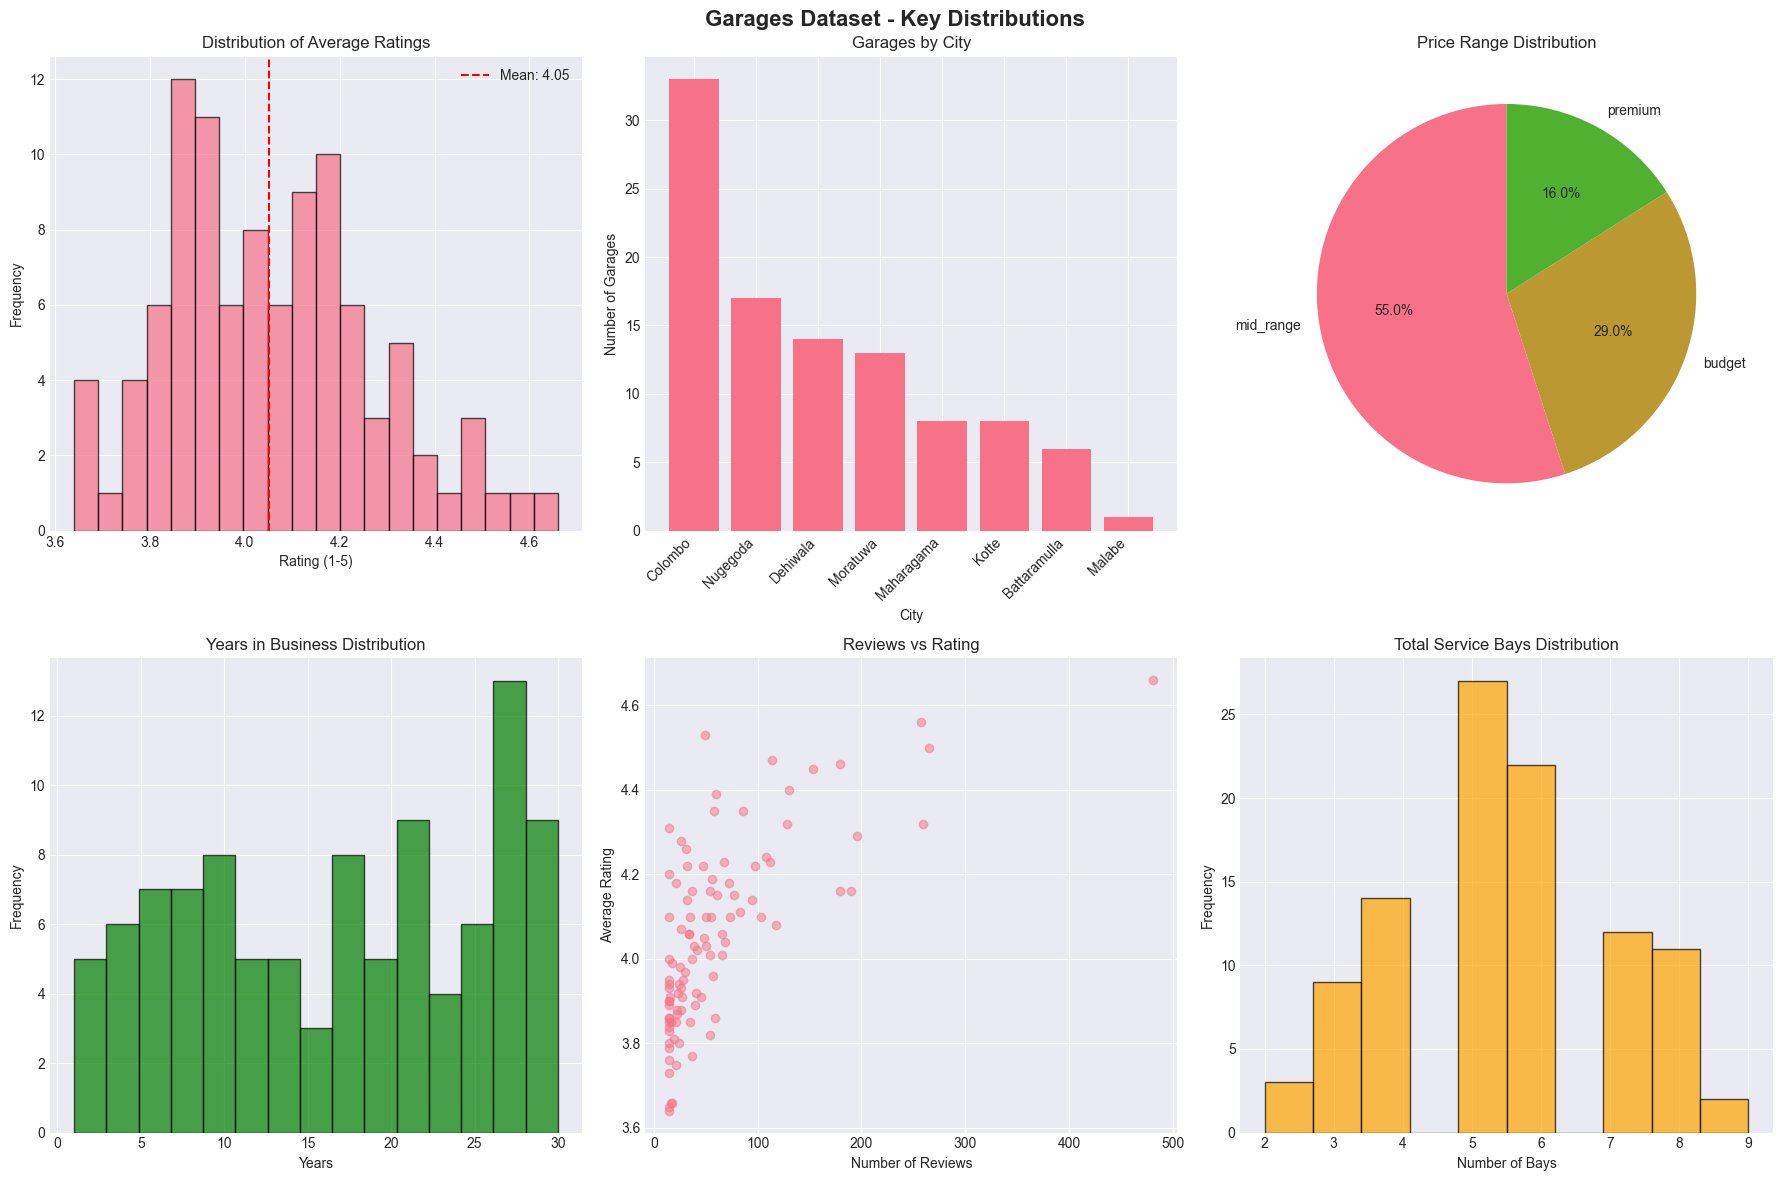


📊 Key Statistics:

Average Rating: 4.05 (±0.22)
Rating Range: 3.64 - 4.66

Number of Cities: 8
Most common city: Colombo

Certified Garages: 60.0%


In [15]:
print("="*80)
print("GARAGES DATASET - EXPLORATORY DATA ANALYSIS")
print("="*80)

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Garages Dataset - Key Distributions', fontsize=16, fontweight='bold')

# 1. Rating distribution
if 'avg_rating' in garages_df.columns:
    axes[0, 0].hist(garages_df['avg_rating'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Distribution of Average Ratings')
    axes[0, 0].set_xlabel('Rating (1-5)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(garages_df['avg_rating'].mean(), color='red', linestyle='--', 
                       label=f"Mean: {garages_df['avg_rating'].mean():.2f}")
    axes[0, 0].legend()

# 2. City distribution
if 'city' in garages_df.columns:
    city_counts = garages_df['city'].value_counts()
    axes[0, 1].bar(range(len(city_counts)), city_counts.values)
    axes[0, 1].set_title('Garages by City')
    axes[0, 1].set_xlabel('City')
    axes[0, 1].set_ylabel('Number of Garages')
    axes[0, 1].set_xticks(range(len(city_counts)))
    axes[0, 1].set_xticklabels(city_counts.index, rotation=45, ha='right')

# 3. Price range distribution
if 'price_range' in garages_df.columns:
    price_counts = garages_df['price_range'].value_counts()
    axes[0, 2].pie(price_counts.values, labels=price_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0, 2].set_title('Price Range Distribution')

# 4. Years in business
if 'years_in_business' in garages_df.columns:
    axes[1, 0].hist(garages_df['years_in_business'], bins=15, edgecolor='black', alpha=0.7, color='green')
    axes[1, 0].set_title('Years in Business Distribution')
    axes[1, 0].set_xlabel('Years')
    axes[1, 0].set_ylabel('Frequency')

# 5. Number of reviews vs rating
if 'num_reviews' in garages_df.columns and 'avg_rating' in garages_df.columns:
    axes[1, 1].scatter(garages_df['num_reviews'], garages_df['avg_rating'], alpha=0.5)
    axes[1, 1].set_title('Reviews vs Rating')
    axes[1, 1].set_xlabel('Number of Reviews')
    axes[1, 1].set_ylabel('Average Rating')

# 6. Total bays distribution
if 'total_bays' in garages_df.columns:
    axes[1, 2].hist(garages_df['total_bays'], bins=10, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 2].set_title('Total Service Bays Distribution')
    axes[1, 2].set_xlabel('Number of Bays')
    axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Key Statistics:")
if 'avg_rating' in garages_df.columns:
    print(f"\nAverage Rating: {garages_df['avg_rating'].mean():.2f} (±{garages_df['avg_rating'].std():.2f})")
    print(f"Rating Range: {garages_df['avg_rating'].min():.2f} - {garages_df['avg_rating'].max():.2f}")

if 'city' in garages_df.columns:
    print(f"\nNumber of Cities: {garages_df['city'].nunique()}")
    print(f"Most common city: {garages_df['city'].mode()[0]}")

if 'certified' in garages_df.columns:
    cert_pct = (garages_df['certified'].sum() / len(garages_df)) * 100
    print(f"\nCertified Garages: {cert_pct:.1f}%")

### 5.2 Repairs Analysis

REPAIRS DATASET - EXPLORATORY DATA ANALYSIS


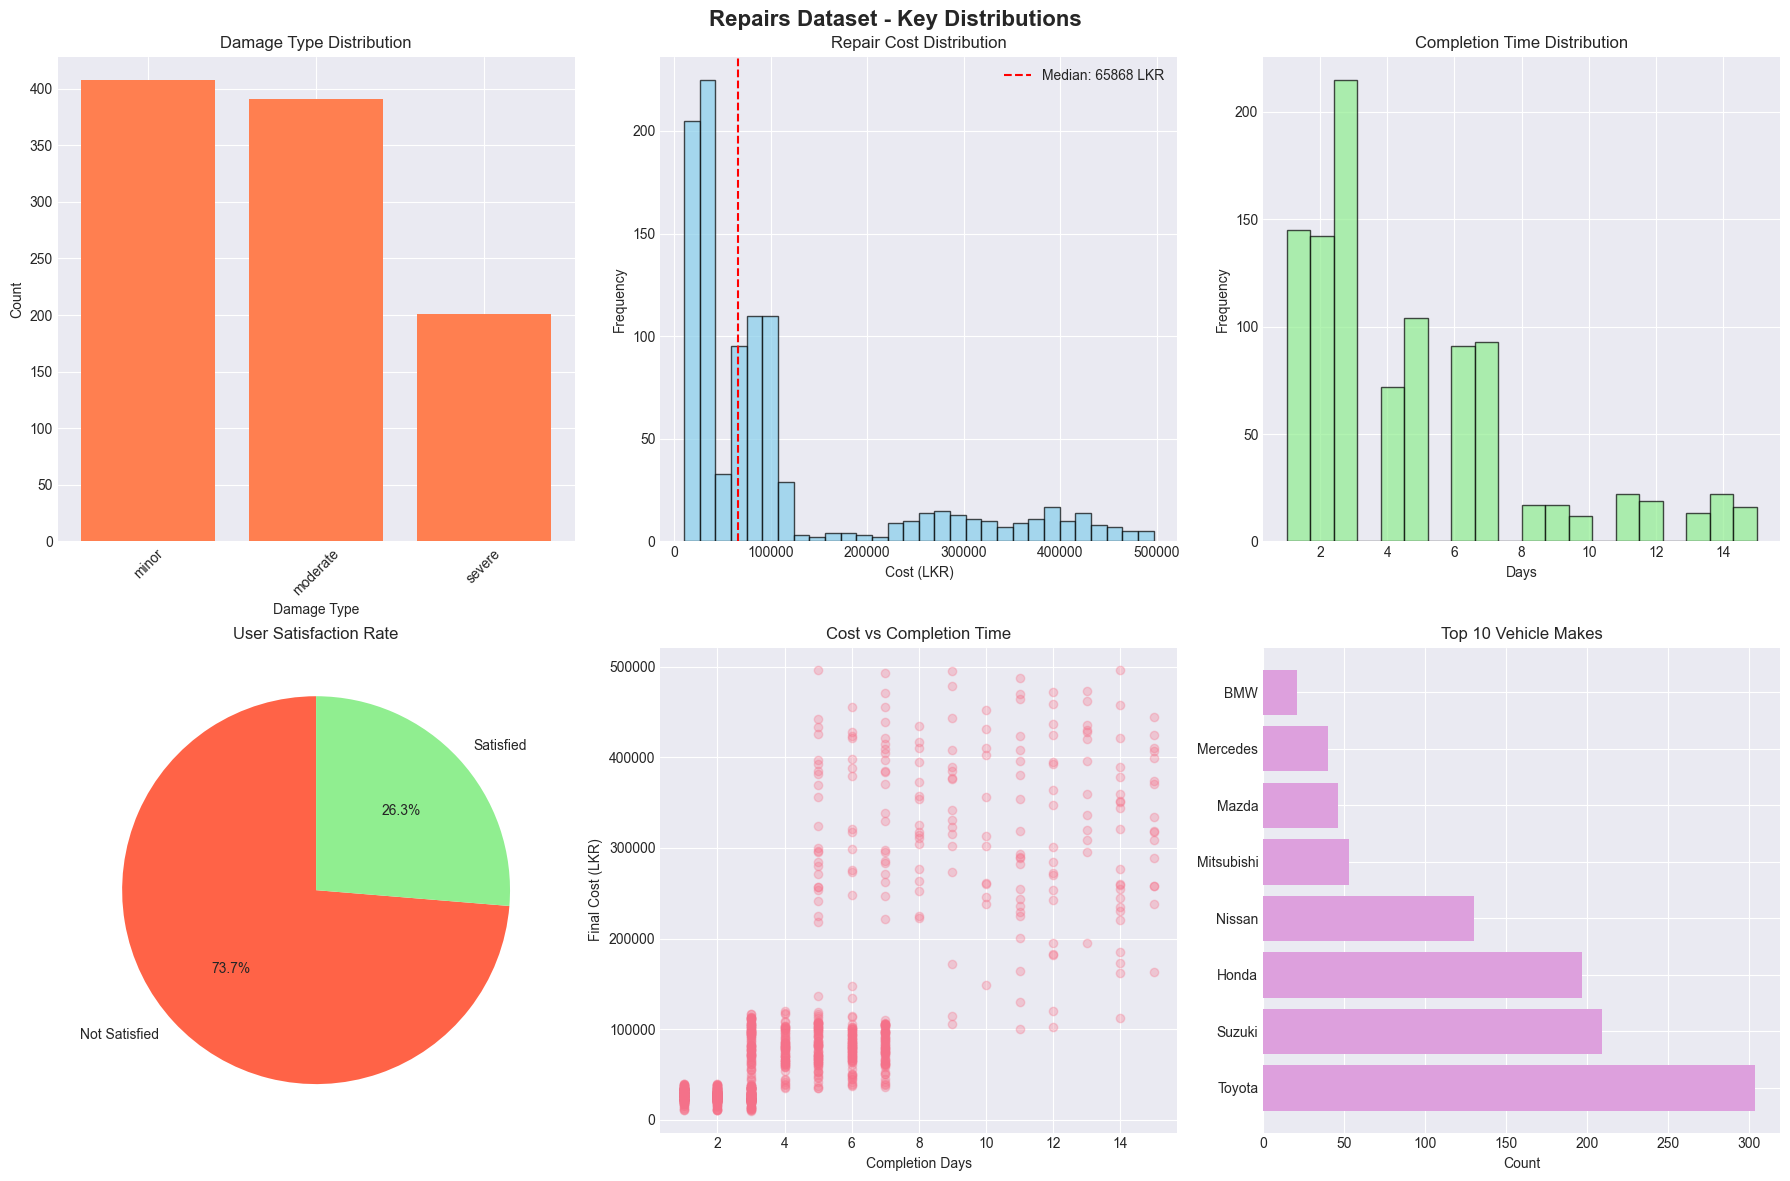


📊 Key Statistics:

Average Repair Cost: 106866.65 LKR
Median Repair Cost: 65867.50 LKR
Cost Range: 10242.00 - 496638.00 LKR

Average Completion Time: 4.67 days
Median Completion Time: 3.00 days

Overall Satisfaction Rate: 73.7%


In [16]:
print("="*80)
print("REPAIRS DATASET - EXPLORATORY DATA ANALYSIS")
print("="*80)

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Repairs Dataset - Key Distributions', fontsize=16, fontweight='bold')

# 1. Damage type distribution
if 'damage_type' in repairs_df.columns:
    damage_counts = repairs_df['damage_type'].value_counts()
    axes[0, 0].bar(damage_counts.index, damage_counts.values, color='coral')
    axes[0, 0].set_title('Damage Type Distribution')
    axes[0, 0].set_xlabel('Damage Type')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Final cost distribution
if 'final_cost' in repairs_df.columns:
    axes[0, 1].hist(repairs_df['final_cost'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Repair Cost Distribution')
    axes[0, 1].set_xlabel('Cost (LKR)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(repairs_df['final_cost'].median(), color='red', linestyle='--',
                       label=f"Median: {repairs_df['final_cost'].median():.0f} LKR")
    axes[0, 1].legend()

# 3. Completion days distribution
if 'completion_days' in repairs_df.columns:
    axes[0, 2].hist(repairs_df['completion_days'], bins=20, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[0, 2].set_title('Completion Time Distribution')
    axes[0, 2].set_xlabel('Days')
    axes[0, 2].set_ylabel('Frequency')

# 4. User satisfaction
if 'user_satisfied' in repairs_df.columns:
    sat_counts = repairs_df['user_satisfied'].value_counts()
    axes[1, 0].pie(sat_counts.values, labels=['Not Satisfied', 'Satisfied'], 
                   autopct='%1.1f%%', startangle=90, colors=['tomato', 'lightgreen'])
    axes[1, 0].set_title('User Satisfaction Rate')

# 5. Cost vs Completion Days
if 'final_cost' in repairs_df.columns and 'completion_days' in repairs_df.columns:
    axes[1, 1].scatter(repairs_df['completion_days'], repairs_df['final_cost'], alpha=0.3)
    axes[1, 1].set_title('Cost vs Completion Time')
    axes[1, 1].set_xlabel('Completion Days')
    axes[1, 1].set_ylabel('Final Cost (LKR)')

# 6. Vehicle make distribution
if 'vehicle_make' in repairs_df.columns:
    make_counts = repairs_df['vehicle_make'].value_counts().head(10)
    axes[1, 2].barh(range(len(make_counts)), make_counts.values, color='plum')
    axes[1, 2].set_title('Top 10 Vehicle Makes')
    axes[1, 2].set_xlabel('Count')
    axes[1, 2].set_yticks(range(len(make_counts)))
    axes[1, 2].set_yticklabels(make_counts.index)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Key Statistics:")
if 'final_cost' in repairs_df.columns:
    print(f"\nAverage Repair Cost: {repairs_df['final_cost'].mean():.2f} LKR")
    print(f"Median Repair Cost: {repairs_df['final_cost'].median():.2f} LKR")
    print(f"Cost Range: {repairs_df['final_cost'].min():.2f} - {repairs_df['final_cost'].max():.2f} LKR")

if 'completion_days' in repairs_df.columns:
    print(f"\nAverage Completion Time: {repairs_df['completion_days'].mean():.2f} days")
    print(f"Median Completion Time: {repairs_df['completion_days'].median():.2f} days")

if 'user_satisfied' in repairs_df.columns:
    satisfaction_rate = (repairs_df['user_satisfied'].sum() / len(repairs_df)) * 100
    print(f"\nOverall Satisfaction Rate: {satisfaction_rate:.1f}%")

### 5.3 Correlation Analysis

CORRELATION ANALYSIS

📊 Repairs Dataset Correlations:


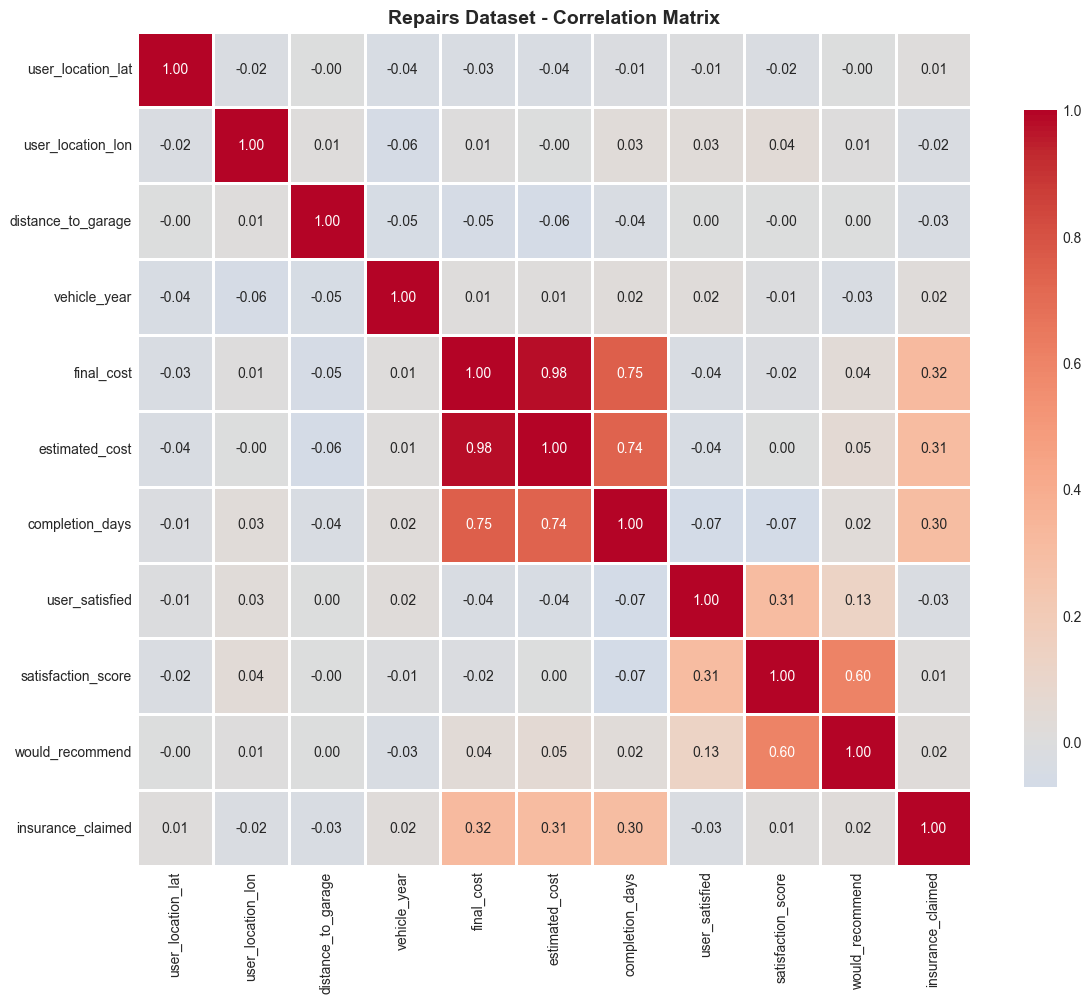


Strong Correlations (|r| > 0.5):


,Feature 1,Feature 2,Correlation
0,final_cost,estimated_cost,0.980
1,final_cost,completion_days,0.755
2,estimated_cost,completion_days,0.738
3,satisfaction_score,would_recommend,0.604



📊 Garages Dataset Correlations:


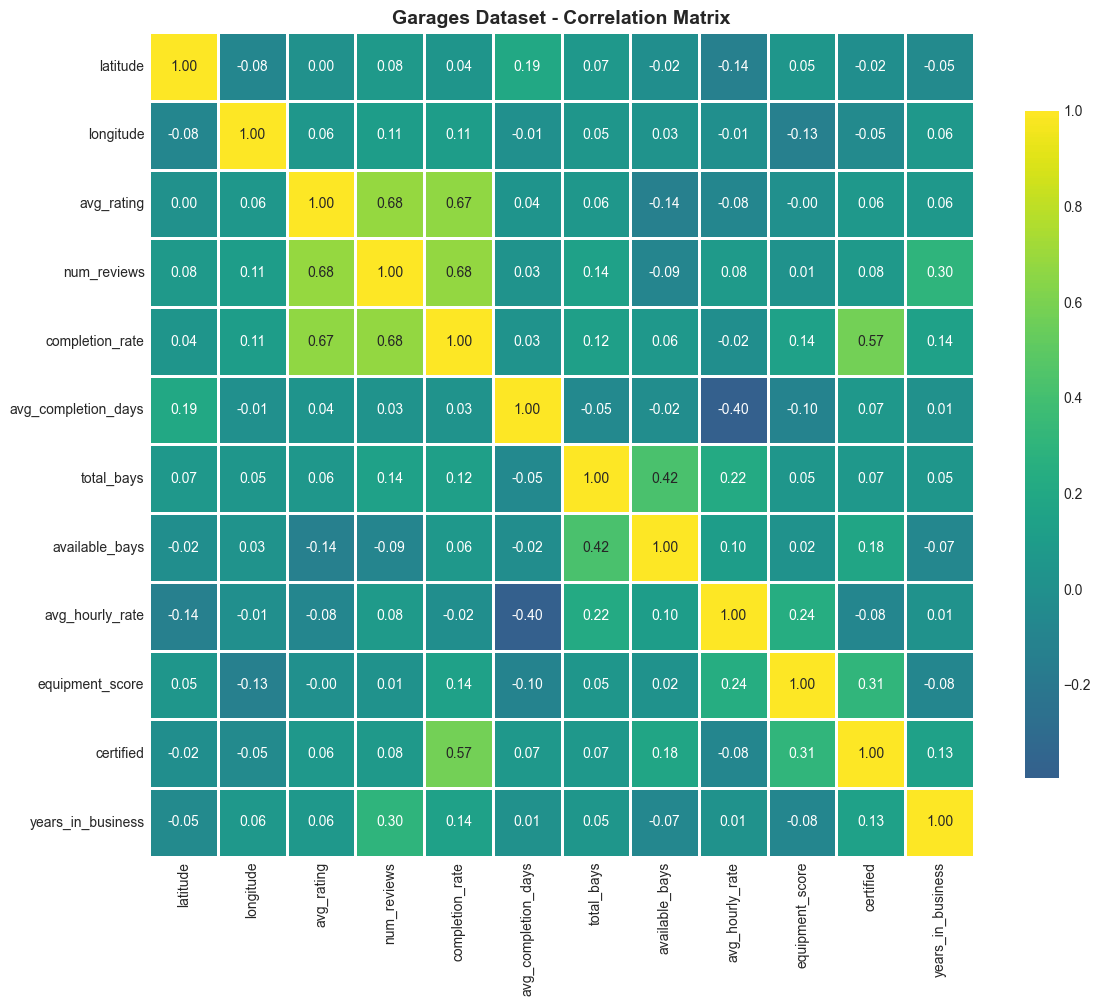

In [17]:
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Repairs dataset correlation
print("\n📊 Repairs Dataset Correlations:")
repairs_numeric = repairs_df.select_dtypes(include=[np.number])

if len(repairs_numeric.columns) > 0:
    # Calculate correlation matrix
    corr_matrix = repairs_numeric.corr()
    
    # Plot heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Repairs Dataset - Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print strong correlations
    print("\nStrong Correlations (|r| > 0.5):")
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                strong_corr.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    
    if strong_corr:
        strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', 
                                                                 key=abs, ascending=False)
        display(strong_corr_df)
    else:
        print("  No strong correlations found.")
else:
    print("  No numeric columns found for correlation analysis.")

# Garages dataset correlation
print("\n📊 Garages Dataset Correlations:")
garages_numeric = garages_df.select_dtypes(include=[np.number])

if len(garages_numeric.columns) > 0:
    corr_matrix_garages = garages_numeric.corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix_garages, annot=True, fmt='.2f', cmap='viridis', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Garages Dataset - Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 5.4 Geographic Distribution

GEOGRAPHIC DISTRIBUTION ANALYSIS


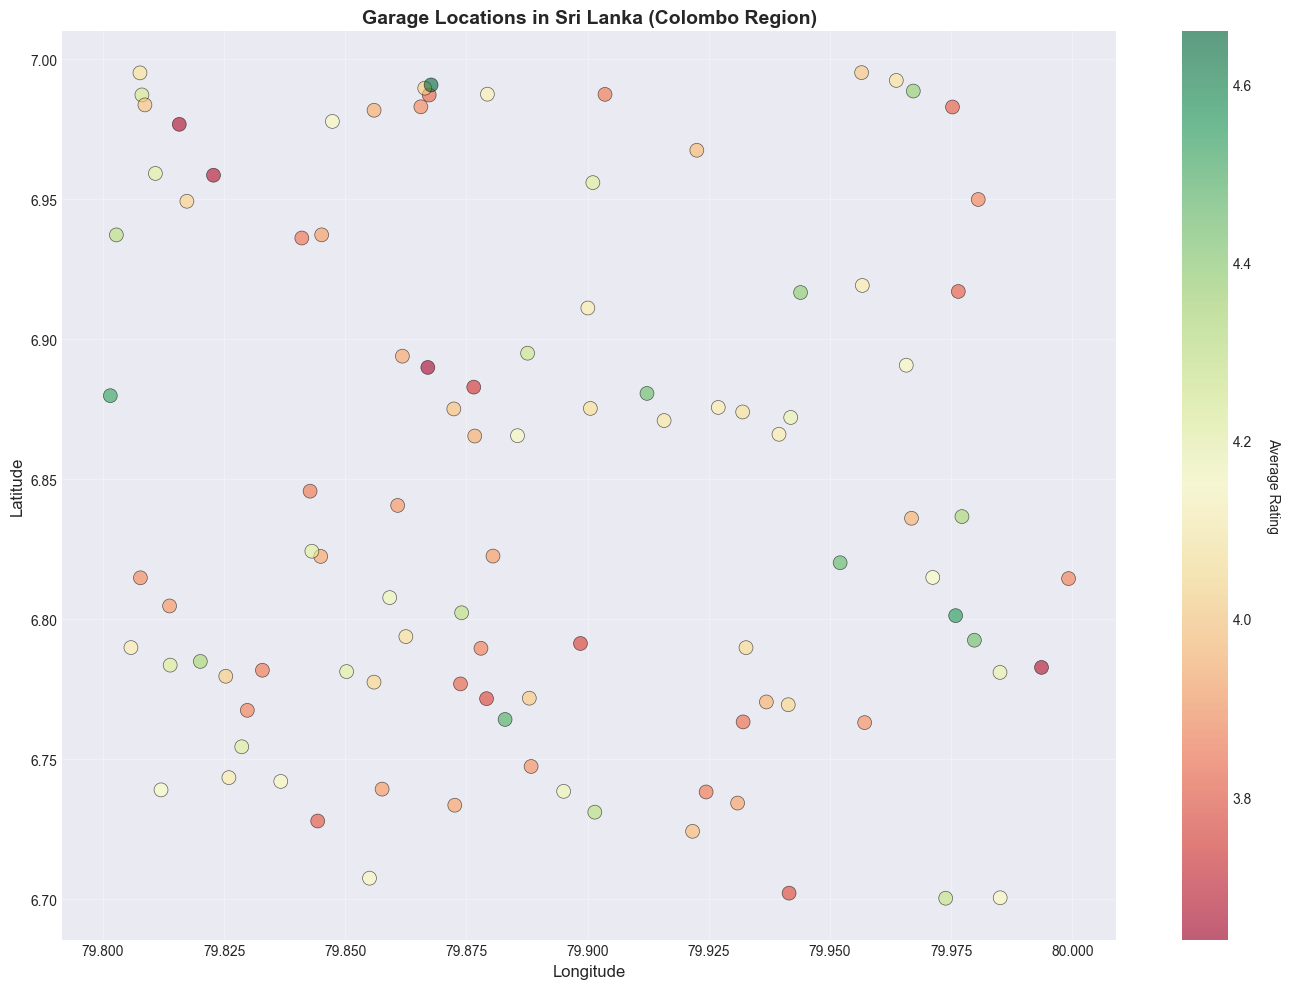


📍 Geographic Statistics:
Latitude Range: 6.7003 to 6.9952
Longitude Range: 79.8015 to 79.9992

Center Point: (6.8468, 79.8896)


In [18]:
print("="*80)
print("GEOGRAPHIC DISTRIBUTION ANALYSIS")
print("="*80)

if 'latitude' in garages_df.columns and 'longitude' in garages_df.columns:
    # Plot garage locations
    plt.figure(figsize=(14, 10))
    
    # Create scatter plot
    scatter = plt.scatter(garages_df['longitude'], garages_df['latitude'], 
                         c=garages_df['avg_rating'] if 'avg_rating' in garages_df.columns else 'blue',
                         cmap='RdYlGn', s=100, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.title('Garage Locations in Sri Lanka (Colombo Region)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    if 'avg_rating' in garages_df.columns:
        cbar = plt.colorbar(scatter)
        cbar.set_label('Average Rating', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📍 Geographic Statistics:")
    print(f"Latitude Range: {garages_df['latitude'].min():.4f} to {garages_df['latitude'].max():.4f}")
    print(f"Longitude Range: {garages_df['longitude'].min():.4f} to {garages_df['longitude'].max():.4f}")
    print(f"\nCenter Point: ({garages_df['latitude'].mean():.4f}, {garages_df['longitude'].mean():.4f})")
else:
    print("  Latitude/Longitude columns not found.")

### 5.5 Time Series Analysis (Capacity)

CAPACITY TIME SERIES ANALYSIS


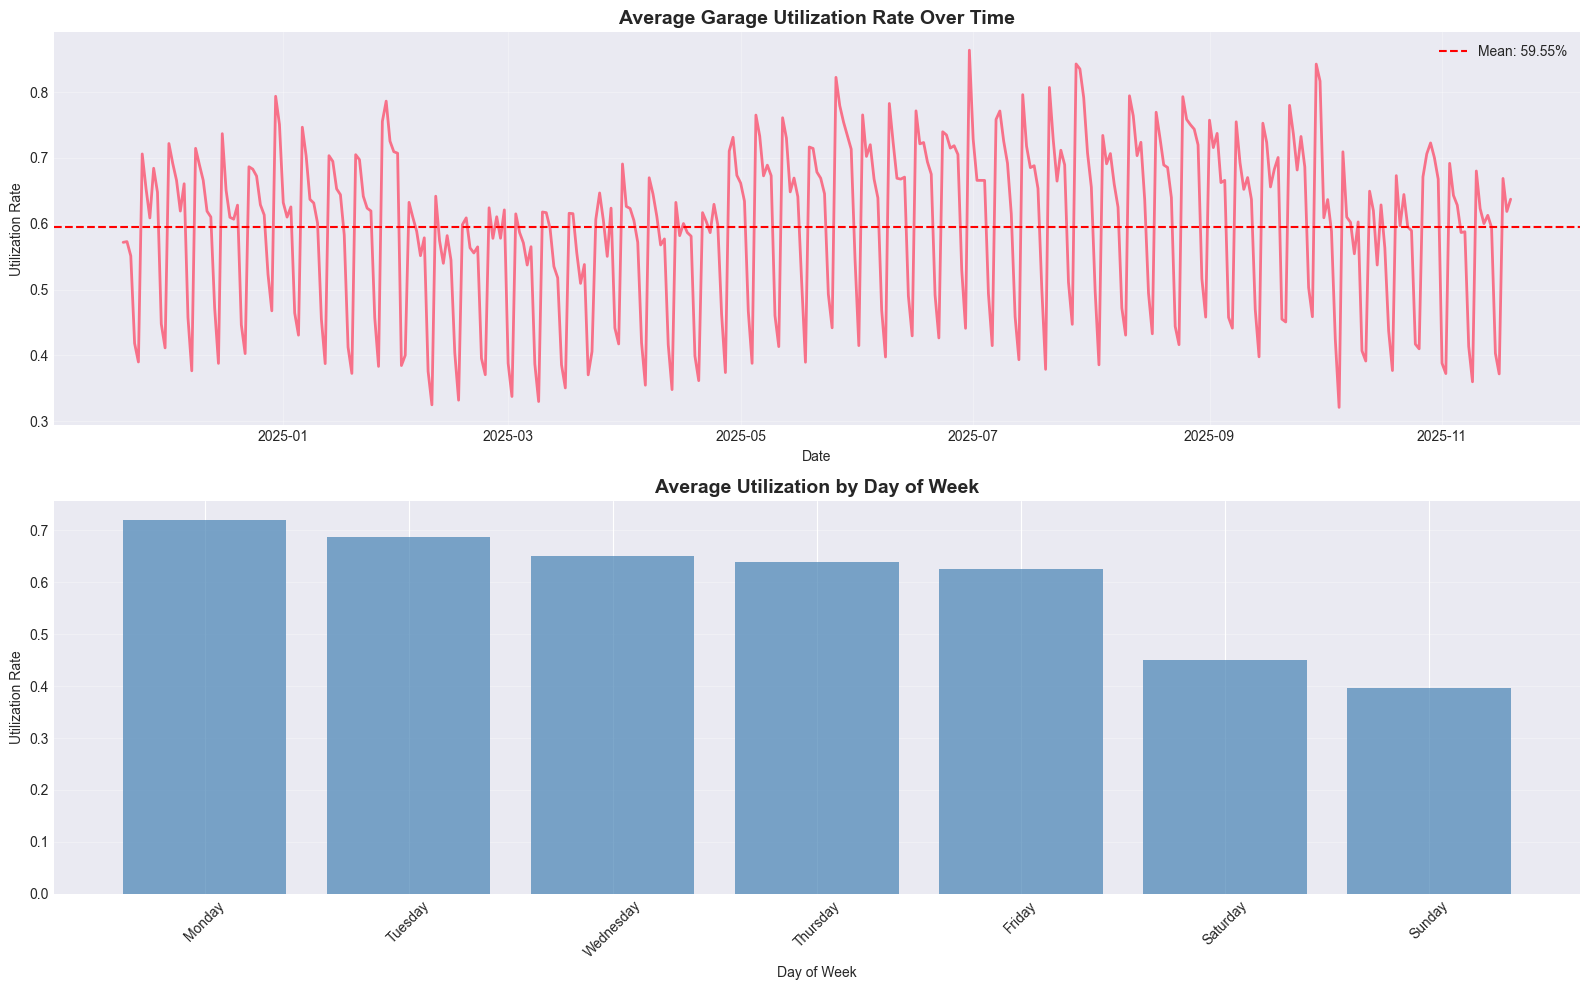


📊 Capacity Statistics:
Average Utilization Rate: 59.55%
Peak Utilization: 100.00%
Lowest Utilization: 0.00%


In [19]:
print("="*80)
print("CAPACITY TIME SERIES ANALYSIS")
print("="*80)

if 'date' in capacity_df.columns and 'utilization_rate' in capacity_df.columns:
    # Convert date if not already
    capacity_df['date'] = pd.to_datetime(capacity_df['date'])
    
    # Calculate average utilization by date
    daily_util = capacity_df.groupby('date')['utilization_rate'].mean().reset_index()
    
    # Plot time series
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # 1. Overall utilization trend
    axes[0].plot(daily_util['date'], daily_util['utilization_rate'], linewidth=2)
    axes[0].set_title('Average Garage Utilization Rate Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Utilization Rate')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=daily_util['utilization_rate'].mean(), color='r', linestyle='--',
                    label=f"Mean: {daily_util['utilization_rate'].mean():.2%}")
    axes[0].legend()
    
    # 2. Day of week analysis
    if 'day_of_week' in capacity_df.columns:
        dow_util = capacity_df.groupby('day_of_week')['utilization_rate'].mean()
        
        # Sort by day order
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dow_util = dow_util.reindex([day for day in day_order if day in dow_util.index])
        
        axes[1].bar(dow_util.index, dow_util.values, color='steelblue', alpha=0.7)
        axes[1].set_title('Average Utilization by Day of Week', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Day of Week')
        axes[1].set_ylabel('Utilization Rate')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Capacity Statistics:")
    print(f"Average Utilization Rate: {capacity_df['utilization_rate'].mean():.2%}")
    print(f"Peak Utilization: {capacity_df['utilization_rate'].max():.2%}")
    print(f"Lowest Utilization: {capacity_df['utilization_rate'].min():.2%}")
else:
    print("  Required columns not found for time series analysis.")

---
<a id='section6'></a>
## 6. Data Validation

### 6.1 Cross-Reference Validation

In [20]:
print("="*80)
print("DATA VALIDATION - CROSS-REFERENCE CHECKS")
print("="*80)

validation_results = []

# Check 1: All garage_ids in repairs exist in garages
if 'garage_id' in repairs_df.columns and 'garage_id' in garages_df.columns:
    repair_garage_ids = set(repairs_df['garage_id'].unique())
    valid_garage_ids = set(garages_df['garage_id'].unique())
    invalid_ids = repair_garage_ids - valid_garage_ids
    
    if len(invalid_ids) == 0:
        validation_results.append(("✅", "Garage ID References", "All repair garage_ids exist in garages dataset"))
    else:
        validation_results.append(("❌", "Garage ID References", f"{len(invalid_ids)} invalid garage_ids found"))
        print(f"  Invalid IDs: {invalid_ids}")

# Check 2: Ratings are in valid range [1, 5]
if 'avg_rating' in garages_df.columns:
    invalid_ratings = garages_df[(garages_df['avg_rating'] < 1) | (garages_df['avg_rating'] > 5)]
    if len(invalid_ratings) == 0:
        validation_results.append(("✅", "Rating Range", "All ratings are between 1 and 5"))
    else:
        validation_results.append(("❌", "Rating Range", f"{len(invalid_ratings)} invalid ratings found"))

# Check 3: Available bays <= total bays
if 'available_bays' in garages_df.columns and 'total_bays' in garages_df.columns:
    invalid_capacity = garages_df[garages_df['available_bays'] > garages_df['total_bays']]
    if len(invalid_capacity) == 0:
        validation_results.append(("✅", "Capacity Logic", "Available bays <= total bays for all garages"))
    else:
        validation_results.append(("❌", "Capacity Logic", f"{len(invalid_capacity)} invalid capacity records"))

# Check 4: Costs are positive
if 'final_cost' in repairs_df.columns:
    invalid_costs = repairs_df[repairs_df['final_cost'] <= 0]
    if len(invalid_costs) == 0:
        validation_results.append(("✅", "Cost Values", "All repair costs are positive"))
    else:
        validation_results.append(("❌", "Cost Values", f"{len(invalid_costs)} invalid cost values"))

# Check 5: Coordinates are in Sri Lanka (approximate bounds)
if 'latitude' in garages_df.columns and 'longitude' in garages_df.columns:
    invalid_coords = garages_df[
        (garages_df['latitude'] < 5.9) | (garages_df['latitude'] > 9.9) |
        (garages_df['longitude'] < 79.5) | (garages_df['longitude'] > 82.0)
    ]
    if len(invalid_coords) == 0:
        validation_results.append(("✅", "Geographic Bounds", "All coordinates are within Sri Lanka"))
    else:
        validation_results.append(("⚠️", "Geographic Bounds", f"{len(invalid_coords)} coordinates outside expected range"))

# Check 6: Dates are not in the future
date_cols = [col for col in repairs_df.columns if 'date' in col.lower()]
if date_cols:
    future_dates = 0
    for col in date_cols:
        if pd.api.types.is_datetime64_any_dtype(repairs_df[col]):
            future_dates += (repairs_df[col] > pd.Timestamp.now()).sum()
    
    if future_dates == 0:
        validation_results.append(("✅", "Date Validity", "No future dates found"))
    else:
        validation_results.append(("⚠️", "Date Validity", f"{future_dates} future dates found"))

# Check 7: User IDs in repairs exist (if user_id column exists)
if 'user_id' in repairs_df.columns and 'user_id' in users_df.columns:
    repair_user_ids = set(repairs_df['user_id'].unique())
    valid_user_ids = set(users_df['user_id'].unique())
    invalid_user_ids = repair_user_ids - valid_user_ids
    
    if len(invalid_user_ids) == 0:
        validation_results.append(("✅", "User ID References", "All repair user_ids exist in users dataset"))
    else:
        validation_results.append(("❌", "User ID References", f"{len(invalid_user_ids)} invalid user_ids found"))

# Display validation results
print("\n" + "="*80)
print("VALIDATION RESULTS")
print("="*80 + "\n")

for status, check, message in validation_results:
    print(f"{status} {check:.<50} {message}")

# Summary
passed = sum(1 for r in validation_results if r[0] == "✅")
warnings = sum(1 for r in validation_results if r[0] == "⚠️")
failed = sum(1 for r in validation_results if r[0] == "❌")

print("\n" + "="*80)
print(f"SUMMARY: {passed} Passed | {warnings} Warnings | {failed} Failed")
print("="*80)

if failed == 0:
    print("\n✅ All critical validations passed! Data is ready for modeling.")
else:
    print(f"\n⚠️ {failed} validation(s) failed. Please review and fix before modeling.")

DATA VALIDATION - CROSS-REFERENCE CHECKS

VALIDATION RESULTS

✅ Garage ID References.............................. All repair garage_ids exist in garages dataset
✅ Rating Range...................................... All ratings are between 1 and 5
✅ Capacity Logic.................................... Available bays <= total bays for all garages
✅ Cost Values....................................... All repair costs are positive
✅ Geographic Bounds................................. All coordinates are within Sri Lanka
✅ Date Validity..................................... No future dates found
✅ User ID References................................ All repair user_ids exist in users dataset

SUMMARY: 7 Passed | 0 Warnings | 0 Failed

✅ All critical validations passed! Data is ready for modeling.


### 6.2 Data Quality Summary

In [21]:
print("="*80)
print("FINAL DATA QUALITY SUMMARY")
print("="*80)

datasets = {
    'Garages': garages_df,
    'Repairs': repairs_df,
    'Users': users_df,
    'Damage Reference': damage_ref_df,
    'Spare Parts': spare_parts_df,
    'Specializations': specializations_df,
    'Capacity Timeline': capacity_df
}

summary_data = []

for name, df in datasets.items():
    summary_data.append({
        'Dataset': name,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Missing Values': df.isnull().sum().sum(),
        'Duplicates': df.duplicated().sum(),
        'Memory (MB)': df.memory_usage(deep=True).sum() / 1024**2
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

print(f"\n📊 Total Records: {summary_df['Rows'].sum():,}")
print(f"📊 Total Missing Values: {summary_df['Missing Values'].sum():,}")
print(f"📊 Total Memory Usage: {summary_df['Memory (MB)'].sum():.2f} MB")

FINAL DATA QUALITY SUMMARY


,Dataset,Rows,Columns,Missing Values,Duplicates,Memory (MB)
0,Garages,100,17,0,0,0.044
1,Repairs,1000,20,0,0,0.594
2,Users,400,16,0,0,0.157
3,Damage Reference,90,15,0,0,0.061
4,Spare Parts,819,6,24,0,0.221
5,Specializations,294,10,0,0,0.086
6,Capacity Timeline,36500,12,0,0,11.115



📊 Total Records: 39,203
📊 Total Missing Values: 24
📊 Total Memory Usage: 12.28 MB


---
<a id='section7'></a>
## 7. Save Cleaned Data

In [23]:
# Create output directory
import os
output_dir = 'data/processed/'
os.makedirs(output_dir, exist_ok=True)

print("💾 Saving cleaned datasets...\n")

# Save cleaned datasets
garages_df.to_csv(output_dir + 'garages_clean.csv', index=False)
print(f"✓ Saved: garages_clean.csv ({len(garages_df)} rows)")

repairs_df.to_csv(output_dir + 'repairs_clean.csv', index=False)
print(f"✓ Saved: repairs_clean.csv ({len(repairs_df)} rows)")

users_df.to_csv(output_dir + 'users_clean.csv', index=False)
print(f"✓ Saved: users_clean.csv ({len(users_df)} rows)")

damage_ref_df.to_csv(output_dir + 'damage_reference_clean.csv', index=False)
print(f"✓ Saved: damage_reference_clean.csv ({len(damage_ref_df)} rows)")

spare_parts_df.to_csv(output_dir + 'spare_parts_clean.csv', index=False)
print(f"✓ Saved: spare_parts_clean.csv ({len(spare_parts_df)} rows)")

specializations_df.to_csv(output_dir + 'specializations_clean.csv', index=False)
print(f"✓ Saved: specializations_clean.csv ({len(specializations_df)} rows)")

capacity_df.to_csv(output_dir + 'capacity_clean.csv', index=False)
print(f"✓ Saved: capacity_clean.csv ({len(capacity_df)} rows)")

print("\n✅ All cleaned datasets saved successfully!")
print(f"📁 Location: {output_dir}")

💾 Saving cleaned datasets...

✓ Saved: garages_clean.csv (100 rows)
✓ Saved: repairs_clean.csv (1000 rows)
✓ Saved: users_clean.csv (400 rows)
✓ Saved: damage_reference_clean.csv (90 rows)
✓ Saved: spare_parts_clean.csv (819 rows)
✓ Saved: specializations_clean.csv (294 rows)
✓ Saved: capacity_clean.csv (36500 rows)

✅ All cleaned datasets saved successfully!
📁 Location: data/processed/
